In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/solomonameh/spotify-music-dataset/low_popularity_spotify_data.csv
/kaggle/input/datasets/solomonameh/spotify-music-dataset/high_popularity_spotify_data.csv


In [2]:
low_df = pd.read_csv("/kaggle/input/datasets/solomonameh/spotify-music-dataset/low_popularity_spotify_data.csv")
high_df = pd.read_csv("/kaggle/input/datasets/solomonameh/spotify-music-dataset/high_popularity_spotify_data.csv")
print(high_df.shape)
print(low_df.shape)
print(high_df.columns)
print(low_df.columns)

(1686, 29)
(3145, 29)
Index(['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness',
       'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness',
       'track_popularity', 'track_href', 'uri', 'track_album_name',
       'playlist_name', 'analysis_url', 'track_id', 'track_name',
       'track_album_release_date', 'instrumentalness', 'track_album_id',
       'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre',
       'type', 'playlist_id'],
      dtype='object')
Index(['time_signature', 'track_popularity', 'speechiness', 'danceability',
       'playlist_name', 'track_artist', 'duration_ms', 'energy',
       'playlist_genre', 'playlist_subgenre', 'track_href', 'track_name',
       'mode', 'uri', 'type', 'track_album_release_date', 'analysis_url', 'id',
       'instrumentalness', 'track_album_id', 'playlist_id', 'track_id',
       'valence', 'key', 'tempo', 'loudness', 'acousticness', 'liveness',
       'track_album_name'],
      dtype='objec

In [3]:
df = pd.concat([high_df, low_df], ignore_index=True)

In [4]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    4830 non-null   float64
 1   tempo                     4830 non-null   float64
 2   danceability              4830 non-null   float64
 3   playlist_genre            4831 non-null   object 
 4   loudness                  4830 non-null   float64
 5   liveness                  4830 non-null   float64
 6   valence                   4830 non-null   float64
 7   track_artist              4831 non-null   object 
 8   time_signature            4830 non-null   float64
 9   speechiness               4830 non-null   float64
 10  track_popularity          4831 non-null   int64  
 11  track_href                4830 non-null   object 
 12  uri                       4830 non-null   object 
 13  track_album_name          4830 non-null   object 
 14  playlist

(4831, 29)

In [5]:
df.isnull().sum()

energy                      1
tempo                       1
danceability                1
playlist_genre              0
loudness                    1
liveness                    1
valence                     1
track_artist                0
time_signature              1
speechiness                 1
track_popularity            0
track_href                  1
uri                         1
track_album_name            1
playlist_name               0
analysis_url                1
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            1
track_album_id              0
mode                        1
key                         1
duration_ms                 1
acousticness                1
id                          1
playlist_subgenre           0
type                        1
playlist_id                 0
dtype: int64

In [6]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(4786, 29)

In [7]:
df["duration_min"] = df["duration_ms"] / 60000
df["duration_min"] = df["duration_min"].round(2)
df[["duration_ms","duration_min"]].head()

,duration_ms,duration_min
0,251668.0,4.19
1,210373.0,3.51
2,166300.0,2.77
3,157280.0,2.62
4,169917.0,2.83


In [8]:
df = df.drop(columns=["duration_ms"])

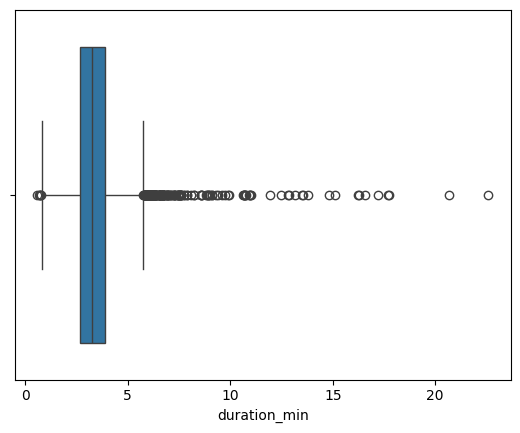

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df["duration_min"])
plt.show()

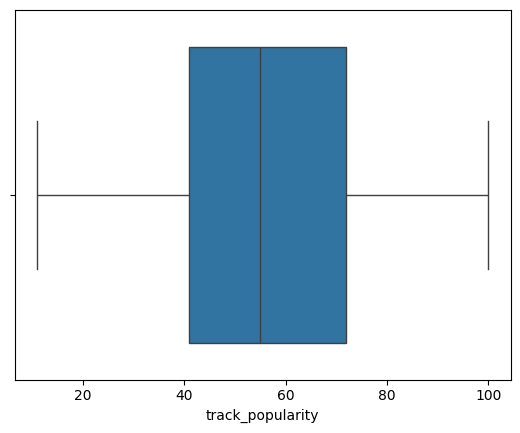

In [10]:
sns.boxplot(x=df["track_popularity"])
plt.show()

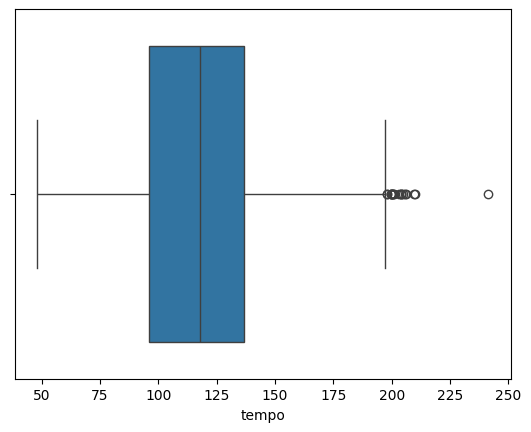

In [11]:
sns.boxplot(x=df["tempo"])
plt.show()

In [12]:
Q1 = df["duration_min"].quantile(0.25)
Q3 = df["duration_min"].quantile(0.75)

IQR = Q3 - Q1

df = df[(df["duration_min"] >= Q1 - 1.5*IQR) & (df["duration_min"] <= Q3 + 1.5*IQR)]

In [13]:
Q1 = df["tempo"].quantile(0.25)
Q3 = df["tempo"].quantile(0.75)

IQR = Q3 - Q1

df = df[(df["tempo"] >= Q1 - 1.5*IQR) & (df["tempo"] <= Q3 + 1.5*IQR)]

In [14]:
df.corr(numeric_only=True)

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,track_popularity,instrumentalness,mode,key,acousticness,duration_min
energy,1.000000,0.202831,0.387811,0.798996,0.195627,0.496686,0.191279,0.131974,0.201827,-0.573360,-0.082561,0.041878,-0.751884,0.198847
tempo,0.202831,1.000000,0.026804,0.165067,0.050158,0.083356,-0.014900,0.052305,0.065541,-0.128530,0.009494,0.011453,-0.179417,0.059905
danceability,0.387811,0.026804,1.000000,0.564519,0.009314,0.510427,0.198026,0.258693,0.133647,-0.355357,-0.121689,0.027588,-0.376549,-0.099226
loudness,0.798996,0.165067,0.564519,1.000000,0.154151,0.471851,0.214806,0.174538,0.217335,-0.645869,-0.101105,0.045982,-0.650454,0.164721
liveness,0.195627,0.050158,0.009314,0.154151,1.000000,0.073437,0.031345,0.098730,0.025284,-0.119831,-0.011526,0.002656,-0.141094,-0.030136
valence,0.496686,0.083356,0.510427,0.471851,0.073437,1.000000,0.138827,0.153797,0.100295,-0.429508,-0.061419,0.036896,-0.356195,0.026139
time_signature,0.191279,-0.014900,0.198026,0.214806,0.031345,0.138827,1.000000,0.109763,0.004629,-0.142285,-0.000623,0.001303,-0.197757,0.010913
speechiness,0.131974,0.052305,0.258693,0.174538,0.098730,0.153797,0.109763,1.000000,0.010889,-0.203644,-0.084692,0.011432,-0.124226,-0.095286
track_popularity,0.201827,0.065541,0.133647,0.217335,0.025284,0.100295,0.004629,0.010889,1.000000,-0.260199,0.002615,0.030335,-0.240882,0.146254
instrumentalness,-0.573360,-0.128530,-0.355357,-0.645869,-0.119831,-0.429508,-0.142285,-0.203644,-0.260199,1.000000,0.030022,-0.029666,0.522098,-0.282989


In [15]:
df = df.drop(columns=["uri"])
df = df.drop(columns=["track_id"])
df = df.drop(columns=["playlist_id"])

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() 
df['loudness'] = scaler.fit_transform(df[['loudness']])

In [17]:
df.to_csv("spotify_cleaned.csv", index=False)